In [2]:
import sys
sys.path.append("../../..")
import torch
from torch.distributions import Normal
from sbi.inference import NPE_A
from sbi.analysis import pairplot
import numpy as np
import matplotlib.pyplot as plt
import scipy

We hypothesize that SNPE-A will struggle to provide a good posterior approximation when the prior (or proposal) mass is far from the posterior mass. 

We can test this in 1D by considering the following example:

$$p(\theta) = N(\theta ; 0, 1)$$

$$p(x|\theta) = N(x; \theta , 1)$$

where we observe $x_\text{obs}\in \{0,1,2,3,...\}$ ($x_\text{obs}$ is $x_\text{obs}$ standard deviations above the mean of the prior). In this case, we have a posterior given analytically by

$$p(\theta|x_\text{obs}) = N\left(\theta; \frac{x_\text{obs}}{2}, \frac{1}{2}\right)$$

We expect that, for large enough $x$ (think over $\approx 4\sigma$ away from prior mean), the SNPE-A algorithm will struggle to approximate the true posterior, since it will be extrapolating past the $(x, \theta)$ training pairs. 

Note that the SNPE-A algorithm (and therefore the python implementation from `sbi`) only allows Gaussian or uniform priors.

In [3]:
from src.examples.norm_norm_far_1d import prior_pdf, likelihood_pdf, posterior_pdf, plot_approximate_posterior, prior, simulator

# Amortized Inference with NPE-A

In [21]:
inference = NPE_A(prior=prior, num_components=1)  # (S)NPE-A algorithm (fast epsilon-free inference)
num_simulations = 20000  # number of (theta, x) pairs sampled and trained on
parameter_samples = prior.sample((num_simulations,))  # simulate parameters from prior
data_samples = simulator(parameter_samples)  # simulate data for each parameter
inference = inference.append_simulations(parameter_samples, data_samples)
density_estimator = inference.train(final_round=True)
posterior = inference.build_posterior()

def approximate_posterior(theta, x):
    """
    Output SNPE-A analytical posterior approximation \hat{p}(theta | x)

    theta and x must be 1D torch tensors
    """
    return torch.exp(posterior.potential(theta, x))

 Neural network successfully converged after 25 epochs.

In [22]:
# Can plot histogram of samples OR analytical posterior approximation
# samples = posterior.sample((10000,), x=x_observed)

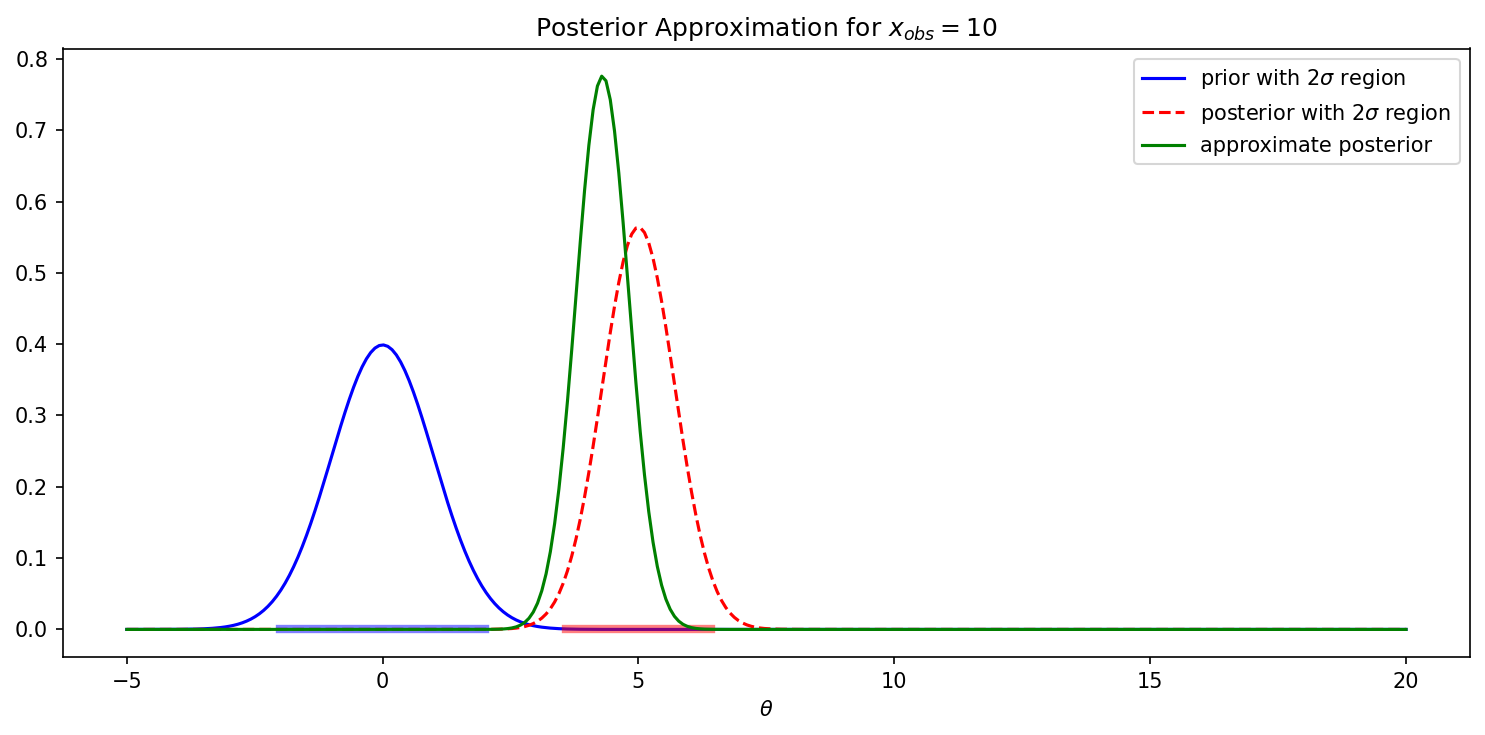

In [23]:
x_observed = 10 # Observed data
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed, title=r"Posterior Approximation for $x_{obs} = $" + f"{x_observed}")

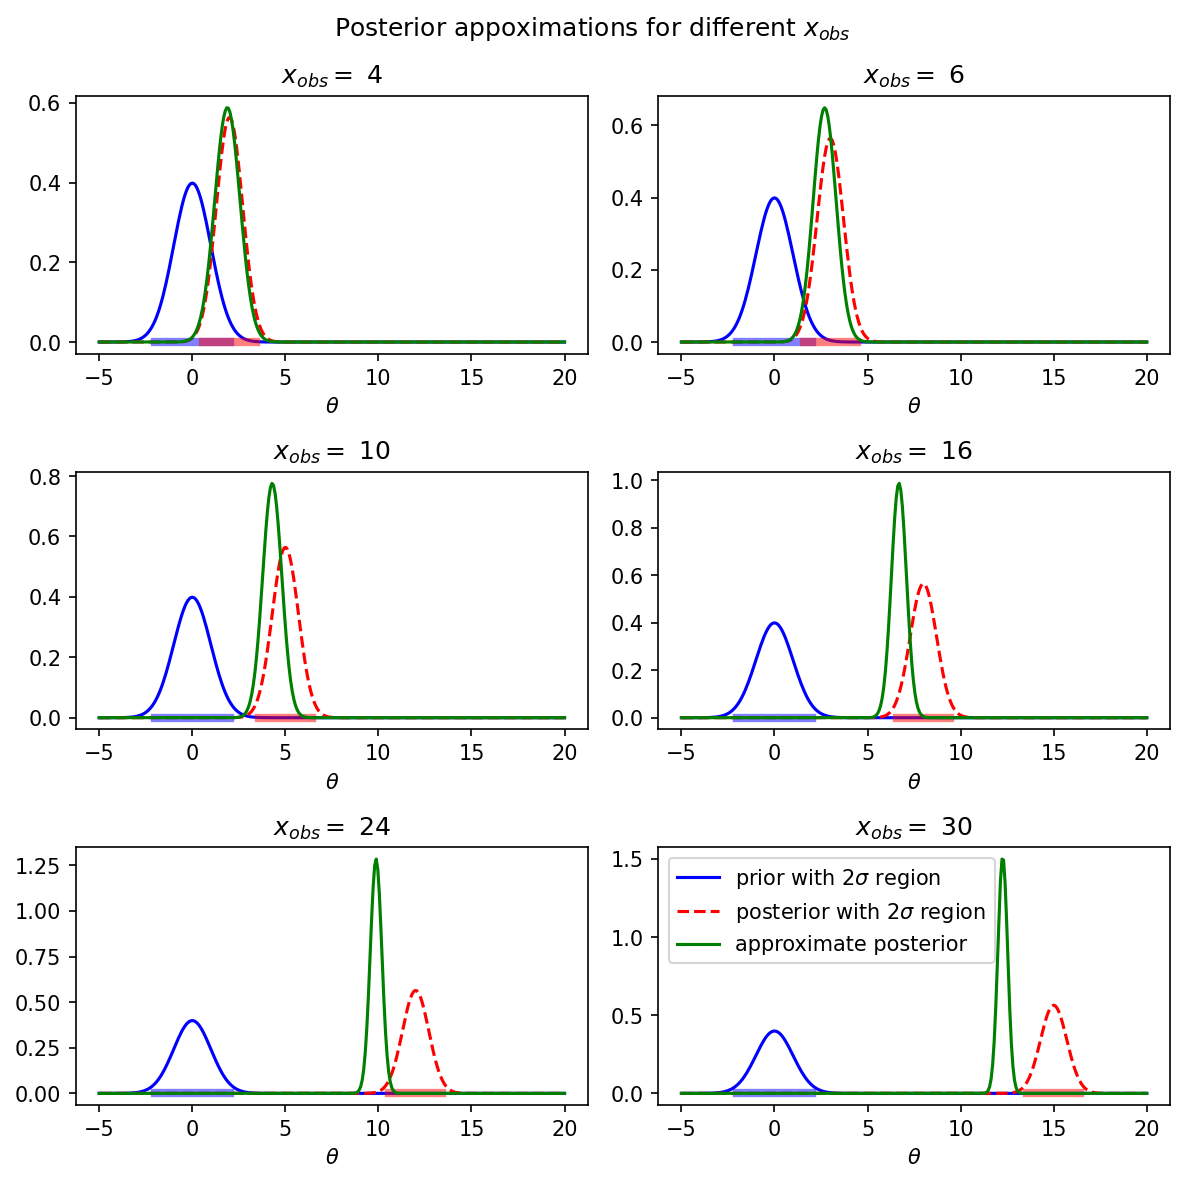

In [24]:
x_observed_values = [4,6,10,16,24,30]
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed_values, title=r"Posterior appoximations for different $x_{obs}$")

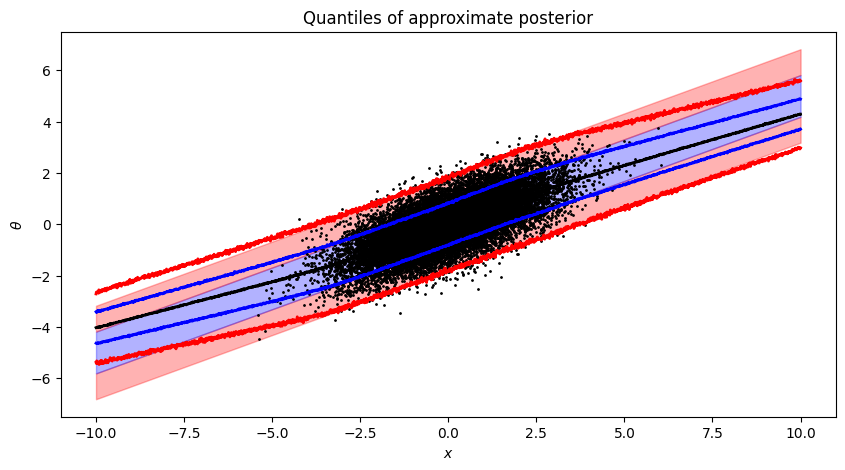

In [28]:
from src.examples.norm_norm_far_1d import approximate_posterior_quantiles_against_x, plot_approximate_posterior_quantiles_against_x

fig, ax = plt.subplots(figsize=(10,5))

x_range = np.linspace(-10,10,2000)
quantiles = approximate_posterior_quantiles_against_x(posterior, x_range)
title = "Quantiles of approximate posterior"
ax = plot_approximate_posterior_quantiles_against_x(x_range, quantiles, title=title, ax=ax)
ax.scatter(data_samples, parameter_samples, s=1, color="k")

### SBC on amortized NPE-A

In [ ]:
from src.sbc.sbc_tools import sbc_ranks, plot_sbc_ecdf, plot_sbc_ecdf_diff, plot_sbc_histogram

In [ ]:
N_iter = 1000
N_samp = 100
ranks = sbc_ranks(simulator, prior, posterior, N_iter=N_iter, N_samp=N_samp)

In [ ]:
fig, ax = plt.subplots(figsize=(10,5), ncols=3)
plot_sbc_histogram(ranks, N_iter, N_samp, ax=ax[0], title=" ")
plot_sbc_ecdf(ranks, N_iter, N_samp, ax=ax[1], title=" ")
plot_sbc_ecdf_diff(ranks, N_iter, N_samp, ax=ax[2], title=" ")
plt.tight_layout()
plt.show()

# Sequential inference with SNPE-A

NOT WORKING DUE TO NON SPD COVARIANCE MATRICES

https://sbi.readthedocs.io/en/latest/how_to_guide/02_multiround_inference.html

In [ ]:
num_sequential_rounds = 3
num_simulations_per_round = 2000
x_observed = 15

inference = NPE_A(prior, num_components=1)
proposal = prior
for r in range(num_sequential_rounds):
    parameter_samples = proposal.sample((num_simulations_per_round,))
    data_samples = simulator(parameter_samples)
    # NPE-A trains a Gaussian density estimator in all but the last round. In the last round,
    # it trains a mixture of Gaussians, which is why we have to pass the `final_round` flag.
    if r == num_sequential_rounds - 1:
        _ = inference.append_simulations(parameter_samples, data_samples, proposal=proposal).train(final_round=True)
        posterior = inference.build_posterior()
    else:
        _ = inference.append_simulations(parameter_samples, data_samples, proposal=proposal).train(final_round=False)
        posterior = inference.build_posterior().set_default_x(x_observed)
        proposal = posterior

In [ ]:
def approximate_posterior(theta, x):
    """
    Output SNPE-A analytical posterior approximation \hat{p}(theta | x)

    theta and x must be 1D torch tensors
    """
    return torch.exp(posterior.potential(theta, x))

In [ ]:
x_observed = 10 # Observed data
theta_range = torch.linspace(-5,20,300).reshape(-1,1)

In [ ]:
approximate_posterior(theta_range, torch.tensor(x_observed))